In [19]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from planetmagfields import Planet
from model import ForwardModel, InverseModel, lcurve_knee, lcurve_distance
from tqdm import tqdm

# Make figures svg
%config InlineBackend.figure_formats = ['svg']

savefigs = False
if savefigs:
    os.makedirs('figures', exist_ok=True)

# Update x/y label and tick font sizes #Too big, need smaller font sizes
plt.rcParams.update({'font.size': 20})
plt.rcParams.update({'xtick.labelsize': 12})
plt.rcParams.update({'ytick.labelsize': 12})
plt.rcParams.update({'legend.fontsize': 12})

## Read data

In [20]:
df = pd.read_csv('./pds_data/uranus48s.csv')

theta = df['Colatitude'] * np.pi / 180
phi = (df['Longitude'] % 360) * np.pi / 180
r = df['Radius']

## Inverse Modeling

## Find optimal $\alpha$

  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [00:01<00:00, 136.14it/s]


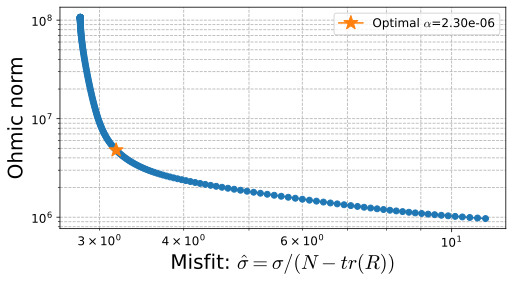

In [21]:
# # Create model
M_inv = InverseModel(lmax=3, r=r, theta=theta, phi=phi,
                 br=df['Br'],
                 btheta=df['Btheta'],
                 bphi=df['Bphi'],
                 smoothing_norm='B2',
                 include_external=True,
                 a=1,b=0.8,c=0.7)


# Define alpha range
alpha_arr = np.logspace(-10, -3, 200)


# Plot trade-off curve
misfit_arr = []
norm_arr = []
for alpha in tqdm(alpha_arr):
    M_inv.solve(alpha=alpha)
    misfit_arr.append(M_inv.misfit_norm)
    norm_arr.append(M_inv.norm_value_ohmic)

# Find optimal alpha (e.g., using L-curve corner)
# We find max curvature point on log-log trade-off curve
# optimal_idx, optimal_alpha, _ = lcurve_knee(alpha_arr, misfit_arr, norm_arr)
optimal_idx, optimal_alpha = lcurve_distance(alpha_arr, misfit_arr, norm_arr)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8,4))
ax.loglog(misfit_arr, norm_arr, marker='o')
ax.loglog(misfit_arr[optimal_idx], norm_arr[optimal_idx], marker='*', markersize=15, label=r'Optimal $\alpha$=%.2e' % optimal_alpha)
ax.legend()
ax.set_xlabel(r'Misfit: $\hat{\sigma} = \sigma/(N-tr(R))$')
ax.set_ylabel('Ohmic norm')
# ax.set_title('Trade-off Curve')
ax.grid(True, which='both', ls='--')
if savefigs:
    plt.savefig('figures/tradeoff_curve.png', dpi=300, bbox_inches='tight')
plt.show()

M_inv.solve(alpha=optimal_alpha)

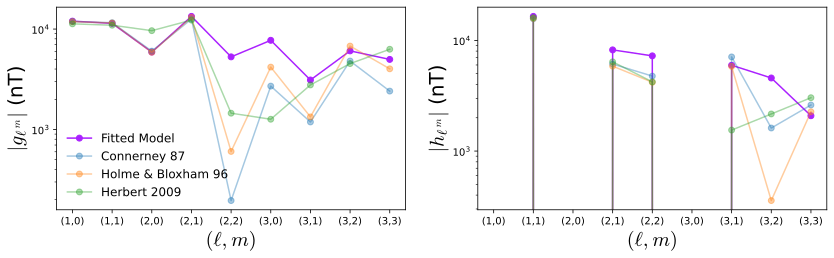

In [22]:
pl1 = Planet(name='Uranus', model='connerney1987', info=False, units='nT')
pl2 = Planet(name='Uranus', model='holme1996', info=False, units='nT')
pl3 = Planet(name='Uranus', model='herbert2009', info=False, units='nT')
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(12,4))
for i in [0,1]:
    if i == 0:
        coeff = M_inv.glm[:9]
        coeff_ref1 = pl1.glm[1:10]
        coeff_ref2 = pl2.glm[1:10]
        coeff_ref3 = pl3.glm[1:10]
        ylabel = r'$|g_{\ell^m}|$ (nT)'
    if i == 1:
        coeff = M_inv.hlm[:9]
        coeff_ref1 = pl1.hlm[1:10]
        coeff_ref2 = pl2.hlm[1:10]
        coeff_ref3 = pl3.hlm[1:10]
        ylabel = r'$|h_{\ell^m}|$ (nT)'

    ax[i].plot(np.abs(coeff),'-o',label='Fitted Model',color='#aa21ff')
    ax[i].plot(np.abs(coeff_ref1),'-o',label='Connerney 87',alpha=0.4)
    ax[i].plot(np.abs(coeff_ref2),'-o',label='Holme & Bloxham 96',alpha=0.4)
    ax[i].plot(np.abs(coeff_ref3),'-o',label='Herbert 2009',alpha=0.4)
    ax[i].set_yscale('log')
    ax[i].set_xlabel(r'$(\ell,m)$',fontsize=20)
    ax[i].set_xticks(np.arange(9))
    ax[i].set_xticklabels(['(1,0)','(1,1)','(2,0)','(2,1)','(2,2)','(3,0)','(3,1)','(3,2)','(3,3)'])
    ax[i].tick_params(axis='both', which='major', labelsize=10)
    ax[i].set_ylabel(ylabel,fontsize=20)

ax[0].legend(frameon=False)
fig.tight_layout()
if savefigs:
    plt.savefig('figures/uranus_fitted_gauss_coefficients.png', dpi=300)
plt.show()

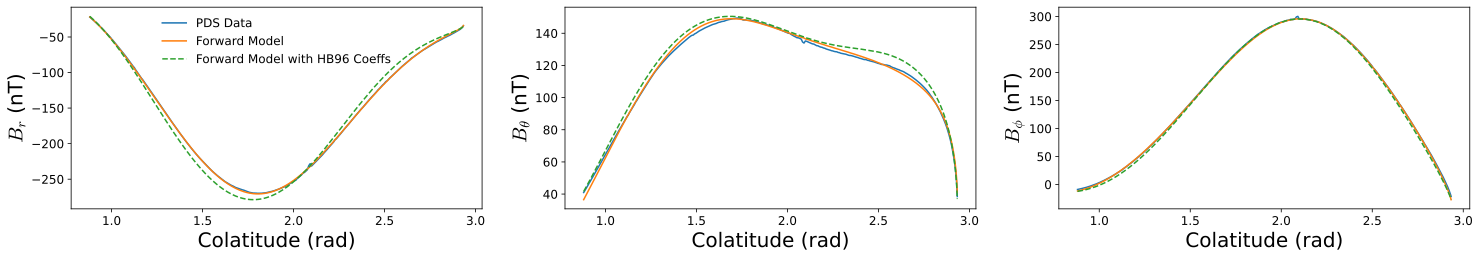

In [5]:
#Test both forward models:

b = np.real(M_inv.A @ M_inv.coeffs)
br = b[0::3]
btheta = b[1::3]
bphi = b[2::3]

# Rearrange Holme and Bloxham 1996 coefficients into same format as M.coeffs
pl = Planet(name='Uranus', model='holme1996', info=False, units='nT')
coeffs_hb = np.zeros(M_inv.ncoeffs)

for l in range(1, min(M_inv.lmax,pl.lmax) + 1):
    for m in range(l + 1):
        # Get coefficient from pl using pl's indexing
        coeffs_hb[M_inv.idx_g[l, m]] = pl.glm[pl.idx[l, m]]

        if m > 0:
            coeffs_hb[M_inv.idx_h[l, m]] = pl.hlm[pl.idx[l, m]]

# Forward model
b_hb = M_inv.A @ coeffs_hb
br_hb = b_hb[0::3]
btheta_hb = b_hb[1::3]
bphi_hb = b_hb[2::3]

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(21, 4), sharex=True)
ax[0].plot(theta, df['Br'], label='PDS Data')
ax[0].plot(theta, br, label='Forward Model')
ax[0].plot(theta, br_hb, label='Forward Model with HB96 Coeffs', linestyle='--')
ax[0].set_ylabel(r'$B_r$ (nT)')
ax[0].set_xlabel('Colatitude (rad)')
ax[0].legend(frameon=False)
ax[1].plot(theta, df['Btheta'])
ax[1].plot(theta, btheta)
ax[1].plot(theta, btheta_hb, linestyle='--')
ax[1].set_ylabel(r'$B_\theta$ (nT)')
ax[1].set_xlabel('Colatitude (rad)')
ax[2].plot(theta, df['Bphi'])
ax[2].plot(theta, bphi)
ax[2].plot(theta, bphi_hb, linestyle='--')
ax[2].set_ylabel(r'$B_\phi$ (nT)')
ax[2].set_xlabel('Colatitude (rad)')
fig.tight_layout()

if savefigs:
    plt.savefig('figures/uranus_forward_model.png', dpi=300)
plt.show()

In [6]:
# Print external coefficients:

print(f"External field coefficients:")
print(f"  G10 = {M_inv.G10:.2f} nT")
print(f"  G11 = {M_inv.G11:.2f} nT")
print(f"  H11 = {M_inv.H11:.2f} nT")

External field coefficients:
  G10 = -7.20 nT
  G11 = -3.81 nT
  H11 = -3.29 nT


In [7]:
# Compare actual values
print("Model glm:", M_inv.glm)
print("Holme & Bloxham glm:", pl.glm[1:])
print("Model hlm:", M_inv.hlm)
print("Holme & Bloxham hlm:", pl.hlm[1:])

Model glm: [ 11877.99180417  11402.35503953  -6509.32337323 -13176.0411419
  -4883.8620071    7132.22645538  -2562.78690298  -5377.65043633
   4381.25450216]
Holme & Bloxham glm: [ 11854.69  11507.23  -5877.08 -13084.9    -604.66   4182.82  -1335.73
  -6776.28  -4021.38]
Model hlm: [     0.         -16417.76545208      0.           8302.44095776
   6900.18779872      0.          -5158.74818577  -4459.28660698
  -2189.79525005]
Holme & Bloxham hlm: [     0.    -15811.9        0.      5850.66    4184.69       0.
  -5816.665   -357.27   -2265.15 ]


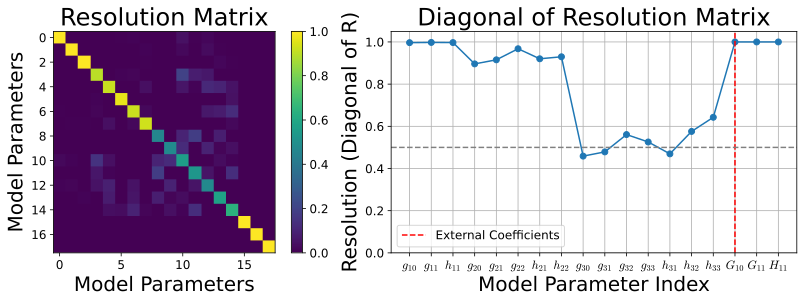

In [8]:
# Plot resolution matrix like Holme & Bloxham 1996
M_inv.resolution_matrix(alpha=optimal_alpha)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 4))
im = ax[0].imshow(M_inv.R, cmap='viridis', vmin=0, vmax=1)
ax[0].set_xlabel('Model Parameters')
ax[0].set_ylabel('Model Parameters')
ax[0].set_title('Resolution Matrix')

ax[1].plot(np.diag(M_inv.R), marker='o')
ax[1].axvline(M_inv.ncoeffs-3, color='red', linestyle='--', label='External Coefficients')
ax[1].set_xlabel('Model Parameter Index')
ax[1].set_ylabel('Resolution (Diagonal of R)')
ax[1].set_title('Diagonal of Resolution Matrix')
ax[1].set_xticks(np.arange(M_inv.ncoeffs))
ax[1].set_xticklabels([r'$g_{10}$',r'$g_{11}$',r'$h_{11}$',
                       r'$g_{20}$',r'$g_{21}$',r'$g_{22}$',r'$h_{21}$',r'$h_{22}$',
                       r'$g_{30}$',r'$g_{31}$',r'$g_{32}$',r'$g_{33}$',r'$h_{31}$',r'$h_{32}$',r'$h_{33}$',
                       r'$G_{10}$',r'$G_{11}$',r'$H_{11}$'])
ax[1].grid()
ax[1].legend()
ax[1].set_ylim(0, 1.05)
ax[1].axhline(0.5, color='gray', linestyle='--')
fig.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04)
if savefigs:
    plt.savefig('figures/uranus_resolution_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

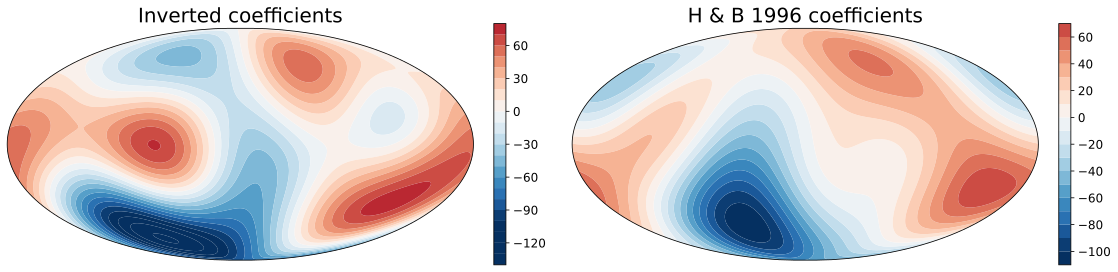

In [9]:
# Plot map of Br
import cartopy.crs as ccrs
from planetmagfields.libgauss import get_grid

p2D, th2D, ph, th = get_grid()

phi = p2D.flatten()
theta = th2D.flatten()
r = np.ones_like(phi)

lon2D = (p2D - np.pi) * 180 / np.pi
lat2D = (np.pi/2 - th2D) * 180 / np.pi

M_fwd = ForwardModel(lmax=M_inv.lmax, r=r, theta=theta, phi=phi, glm=M_inv.glm, hlm=M_inv.hlm, idx_g=M_inv.idx_g, idx_h=M_inv.idx_h)
Br = M_fwd.br.reshape(p2D.shape)/1e3

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16,4), subplot_kw=dict(projection=ccrs.Mollweide()))
im1 = ax[0].contourf(lon2D,lat2D,Br, transform=ccrs.PlateCarree(), levels=20, cmap='RdBu_r',vmin=-100, vmax=100)
im2 = ax[1].contourf(lon2D,lat2D,pl.Br/1e3, transform=ccrs.PlateCarree(), levels=20, cmap='RdBu_r',vmin=-100, vmax=100)
ax[0].set_title("Inverted coefficients",fontsize=20)
ax[1].set_title("H & B 1996 coefficients",fontsize=20)
fig.colorbar(im1, ax=ax[0], fraction=0.046, pad=0.04)
fig.colorbar(im2, ax=ax[1], fraction=0.046, pad=0.04)
fig.tight_layout()
if savefigs:
    plt.savefig("figures/uranus_map_comparison.png",dpi=300,bbox_inches='tight')
plt.show()